# University of Manitoba  
**Winter 2026**

**Student Name 1:** Prince Kanani  
**Student ID:** 8029853


**Student Name 2:** Joshua Mudiwa  
**Student ID:** 7954458

**Course:** DATA 2010 A01 – Tools and Techniques  
**Project Weight:** 15%  
**Instructor:** Lie Ding  
**Date:** 18th February 2026  

**Data Source:** Kaggle — Olympic Summer and Winter Games (1896–2024)  
**Research Focus:** Compare medal outcomes and participation patterns over time (e.g., sex proportions, age-group trends, and top medal countries).

---

# DATA 2010 Project — Olympics (1896–2024)

This notebook follows a clear flow:

1) **Load data** (Cells **1–2**)  
2) **Inspect dataset** (Cells **3–7**)  
3) **Data cleaning** (Cells **8–14**)  
4) **Missing values + outliers** (Cells **15–16**)  
5) **Feature engineering** (Cells **17–19**)  
6) **Interesting facts + summaries** (Cells **20–27**)  
7) **Plots** (Cells **28–29**)  
8) **Export cleaned data** (Cell **30**)  

In [1]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 2) Load dataset
# Update the path if needed.
path = r"C:\Users\princ\OneDrive\Documents\OneDrive\Desktop\olympics_1896_2024.csv"
df = pd.read_csv(path, low_memory=False)

print("Raw shape:", df.shape)
df.head()


Raw shape: (290697, 8)


,sex,age,team,year,season,sports,event,medal
0,M,72,Great Britain,1948,Summer,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",NaN
1,M,72,Latvia,1936,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
2,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Individual",NaN
3,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Team",NaN
4,M,72,Netherlands,1928,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN


In [10]:
# 3) Standardize column names (prevents Year vs year issues)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Columns:", df.columns.tolist())


Columns: ['sex', 'age', 'team', 'year', 'season', 'sports', 'event', 'medal']


In [11]:
# 4) Basic coverage checks
print("Year range:", df["year"].min(), "to", df["year"].max())
print("Seasons:", df["season"].dropna().unique())


Year range: 1896 to 2024
Seasons: ['Summer' 'Winter']


In [12]:
# 5) Quick category distributions
print("\nSex counts (including missing):")
print(df["sex"].value_counts(dropna=False))

print("\nMedal counts (including missing):")
print(df["medal"].value_counts(dropna=False).head(15))



Sex counts (including missing):
sex
M    202596
F     88101
Name: count, dtype: int64

Medal counts (including missing):
medal
NaN       247941
Gold       14407
Bronze     14333
Silver     14016
Name: count, dtype: int64


In [13]:
# 6) Missing values summary (top 20)
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(20))


medal     247941
sex            0
age            0
team           0
year           0
season         0
sports         0
event          0
dtype: int64


In [31]:
# 7) How many teams / sports / events?
print("# unique teams:", df["team"].nunique(dropna=True))
print("# unique sports:", df["sports"].nunique(dropna=True))
print("# unique events:", df["event"].nunique(dropna=True))


# unique teams: 1151
# unique sports: 92
# unique events: 1534


In [32]:
# 8) Create a working copy for cleaning
df_clean = df.copy()


In [33]:
# 9) Strip whitespace from all text columns (does NOT turn NaN into 'nan')
text_cols = df_clean.select_dtypes(include="object").columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()


In [34]:
# 10) Fix data type: year must be numeric
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")
df_clean = df_clean.dropna(subset=["year"])
df_clean["year"] = df_clean["year"].astype(int)

print("Cleaned year range:", df_clean["year"].min(), "to", df_clean["year"].max())
print("Shape after year cleaning:", df_clean.shape)


Cleaned year range: 1896 to 2024
Shape after year cleaning: (290697, 8)


In [35]:
# 11) Fix data type: age to numeric (keep float for averages)
if "age" in df_clean.columns:
    df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")
    print("Missing age:", df_clean["age"].isna().sum())
    print("Age range (non-missing):", df_clean["age"].min(), "to", df_clean["age"].max())
else:
    print("Column 'age' not found in this dataset.")


Missing age: 0
Age range (non-missing): 10 to 72


In [36]:
# 12) Standardize medal column
# Fill missing medals with "No medal" and normalize text formatting.
df_clean["medals"] = df_clean["medal"].fillna("No medal")
df_clean["medals"] = df_clean["medal"].str.title().replace({"No Medal": "No medal"})
print(df_clean["medals"].value_counts().head(10))


medals
Gold      14407
Bronze    14333
Silver    14016
Name: count, dtype: int64


In [37]:
# 13) Standardize sex values (M/F)
df_clean["sex"] = df_clean["sex"].replace({"Male": "M", "Female": "F"})
print(df_clean["sex"].value_counts(dropna=False))


sex
M    202596
F     88101
Name: count, dtype: int64


In [38]:
# 14) Remove exact duplicate rows (safe)
dup_count = df_clean.duplicated().sum()
print("Exact duplicates found:", dup_count)

df_clean = df_clean.drop_duplicates()
print("Shape after dropping exact duplicates:", df_clean.shape)


Exact duplicates found: 35568
Shape after dropping exact duplicates: (255129, 9)


In [39]:
# 15) Outlier handling: flag suspicious ages (do NOT delete without justification)
if "age" in df_clean.columns:
    df_clean["age_flag_suspicious"] = (df_clean["age"] < 10) | (df_clean["age"] > 60)
    print("Suspicious age rows:", df_clean["age_flag_suspicious"].sum())

    # Show a few examples
    display(df_clean.loc[df_clean["age_flag_suspicious"], ["age","sports","event","year"]].head(20))


Suspicious age rows: 287


,age,sports,event,year
0,72,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",1948
1,72,Art Competitions,"Art Competitions Mixed Painting, Paintings",1936
2,72,Equestrianism,"Equestrianism Men's Dressage, Individual",1936
3,72,Equestrianism,"Equestrianism Men's Dressage, Team",1936
4,72,Art Competitions,"Art Competitions Mixed Painting, Paintings",1928
5,72,Shooting,"Shooting Men's Running Target, Single Shot",1920
6,72,Shooting,"Shooting Men's Running Target, Single Shot, Team",1920
7,72,Shooting,"Shooting Men's Running Target, Double Shot, Team",1920
8,71,Equestrianism,"Equestrianism Mixed Dressage, Individual",2012
9,71,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",1948


In [43]:
# 16) Missing value handling: impute age using median within (sex, sport)
if "age" in df_clean.columns:
    df_clean["age_imputed"] = df_clean["age"]

    group_median = df_clean.groupby(["sex", "sports"])["age"].transform("median")
    overall_median = df_clean["age"].median()

    df_clean["age_imputed"] = df_clean["age_imputed"].fillna(group_median)
    df_clean["age_imputed"] = df_clean["age_imputed"].fillna(overall_median)

    print("Missing age BEFORE:", df_clean["age"].isna().sum())
    print("Missing age AFTER :", df_clean["age_imputed"].isna().sum())


Missing age BEFORE: 0
Missing age AFTER : 0


In [44]:
# 17) Feature engineering: did the athlete win a medal?
df_clean["won_medal"] = df_clean["medal"].isin(["Gold", "Silver", "Bronze"])
df_clean[["medal","won_medal"]].head()


,medal,won_medal
0,NaN,False
1,NaN,False
2,NaN,False
3,NaN,False
4,NaN,False


In [45]:
# 18) Feature engineering: medal points (Gold=3, Silver=2, Bronze=1, No medal=0)
points_map = {"Gold": 3, "Silver": 2, "Bronze": 1, "No medal": 0}
df_clean["medal_points"] = df_clean["medal"].map(points_map).fillna(0).astype(int)

df_clean[["medal","medal_points"]].head()


,medal,medal_points
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [46]:
# 19) Feature engineering: decade
df_clean["decade"] = (df_clean["year"] // 10) * 10
df_clean["decade"].value_counts().sort_index().head(15)


decade
1890      198
1900     4778
1910     3242
1920    10969
1930     8243
1940     5588
1950    13090
1960    25130
1970    19333
1980    30326
1990    32340
2000    43716
2010    32317
2020    25859
Name: count, dtype: int64

In [47]:
# 20) Interesting fact: sex proportions (counts + %)
sex_counts = df_clean["sex"].value_counts(dropna=False)
sex_percent = (sex_counts / len(df_clean) * 100).round(2)

out = pd.DataFrame({"count": sex_counts, "percent": sex_percent})
out


,count,percent
sex,,
M,177018,69.38
F,78111,30.62


In [54]:
# 21) Interesting fact: age group distribution 
age_col = "age_imputed" if "age_imputed" in df_clean.columns else ("age" if "age" in df_clean.columns else None)

if age_col is None:
    print("No age column available.")
else:
    bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
    labels = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

    df_clean["age_group"] = pd.cut(df_clean[age_col], bins=bins, labels=labels, right=True)
    age_group_counts = df_clean["age_group"].value_counts(dropna=False).sort_index()
    age_group_percent = (age_group_counts / age_group_counts.sum() * 100).round(2)

    pd.DataFrame({"count": age_group_counts, "percent": age_group_percent})

result = pd.DataFrame({"count": age_group_counts, "percent": age_group_percent})
display(result)     
# or
print(result)        


,count,percent
age_group,,
<16,2917,1.14
16-18,16230,6.36
19-25,122217,47.90
26-30,69066,27.07
31-35,28137,11.03
36-40,9495,3.72
41-50,5593,2.19
51+,1474,0.58


            count  percent
age_group                 
<16          2917     1.14
16-18       16230     6.36
19-25      122217    47.90
26-30       69066    27.07
31-35       28137    11.03
36-40        9495     3.72
41-50        5593     2.19
51+          1474     0.58


In [55]:
# 22) Create medalists-only data (exclude 'No medal')
medalists = df_clean[df_clean["medal"].isin(["Gold","Silver","Bronze"])].copy()
print("Medalists shape:", medalists.shape)


Medalists shape: (36217, 15)


In [58]:
# 23) Medal counts by country 
# Meaning: counts medal "rows" in the dataset.
# NOTE: Team events inflate this count because every athlete on the team has a medal row.

# Keep only medal-winning rows
# Count medals by country using country name column "team"
country_medals_athlete = medalists.groupby("team").size().sort_values(ascending=False)

# Show top 10
country_medals_athlete.head(10)

team
United States    4660
Soviet Union     2025
Germany          1800
Great Britain    1626
France           1544
Italy            1429
Sweden           1223
Australia        1220
Canada           1087
Russia           1082
dtype: int64

In [67]:
# 25) Top 7 countries with most medals (EVENT-MEDAL method)
# Meaning: counts unique medals per event per country.
# This avoids team-event inflation by counting each (year, event, team, medal) only once.

# Deduplicate medals so team medals count once per event
event_medals = medalists.drop_duplicates(["year", "event", "team", "medal"])
print("Event-medals shape (unique event medals):", event_medals.shape)

# Count unique event medals by country
country_medals_event = event_medals.groupby("team").size().sort_values(ascending=False)

# Top 7 countries
top7 = country_medals_event.head(7)
top7

Event-medals shape (unique event medals): (20890, 15)


team
United States    2875
Soviet Union     1172
Germany          1017
Great Britain     915
France            886
Italy             768
China             696
dtype: int64

In [70]:
# 24) Countries with the least medals (among medal-winning NOCs)
least = country_medals_event.tail(10)
least


team
Ivory Coast                  1
Italia                       1
Irene                        1
Ireland-3                    1
Ireland-2                    1
Independent Rowing Club-3    1
Hurlingham-2                 1
Humbug V                     1
Hong Kong-2                  1
Zut                          1
dtype: int64

In [72]:
# 26) Countries with exactly 1 medal (athlete-medal method)
one_medal = country_medals_athlete[country_medals_athlete == 1]

print("Number of countries with exactly 1 medal:", one_medal.shape[0])
print("\nCountries with exactly 1 medal:")
print(one_medal.sort_index())

Number of countries with exactly 1 medal: 66

Countries with exactly 1 medal:
team
Andorra                         1
Barbados                        1
Berliner Ruderclub              1
Bolivia                         1
Bonaparte                       1
                               ..
Tonga                           1
Turkmenistan                    1
Turquoise-1                     1
United States Virgin Islands    1
Widgeon                         1
Length: 66, dtype: int64


In [77]:
# 27) Countries with most Gold / Silver / Bronze (event-medal method)
# Using "team" because this dataset does not include NOC country codes.

gold = (
    event_medals[event_medals["medal"] == "Gold"]
    .groupby("team").size()
    .sort_values(ascending=False)
    .head(10)
)

silver = (
    event_medals[event_medals["medal"] == "Silver"]
    .groupby("team").size()
    .sort_values(ascending=False)
    .head(10)
)

bronze = (
    event_medals[event_medals["medal"] == "Bronze"]
    .groupby("team").size()
    .sort_values(ascending=False)
    .head(10)
)

print("Top Gold:\n", gold)
print("\nTop Silver:\n", silver)
print("\nTop Bronze:\n", bronze)

Top Gold:
 team
United States    1141
Soviet Union      459
Germany           321
Great Britain     281
China             278
France            274
Italy             265
Russia            211
Sweden            206
Japan             202
dtype: int64

Top Silver:
 team
United States    925
Soviet Union     365
Germany          351
Great Britain    317
France           285
Italy            236
China            223
Sweden           215
Russia           200
Australia        190
dtype: int64

Top Bronze:
 team
United States    809
Soviet Union     348
Germany          345
France           327
Great Britain    317
Italy            267
Sweden           244
Australia        226
Russia           217
Japan            210
dtype: int64


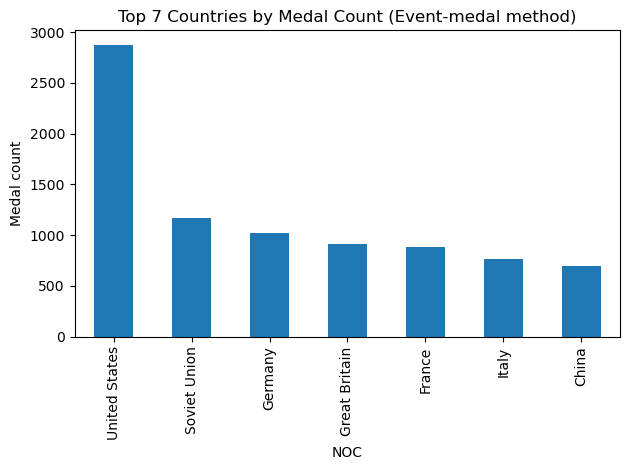

In [74]:
# 28) Plot: Top 7 countries by medals (event-medal method)
plt.figure()
top7.plot(kind="bar")
plt.title("Top 7 Countries by Medal Count (Event-medal method)")
plt.xlabel("NOC")
plt.ylabel("Medal count")
plt.tight_layout()
plt.show()


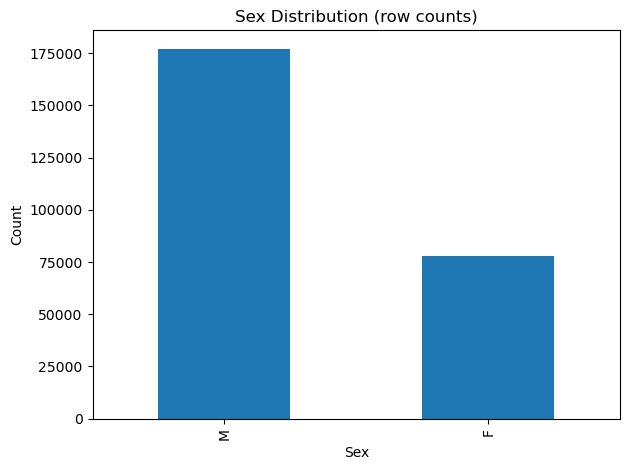

In [75]:
# 29) Plot: Sex distribution (rows)
sex_counts = df_clean["sex"].value_counts(dropna=False)
plt.figure()
sex_counts.plot(kind="bar")
plt.title("Sex Distribution (row counts)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [76]:
# 30) Save cleaned dataset for later steps (optional)
# Make sure you have a 'data' folder beside your notebook.
import os
os.makedirs("data", exist_ok=True)

df_clean.to_csv("data/olympics_cleaned.csv", index=False)
print("Saved: data/olympics_cleaned.csv")


Saved: data/olympics_cleaned.csv
